# Chapter 45 — PyTorch Modules and Parameters

## Learning goals

Chapter 44 used autograd with separate leaf tensors for a weight and bias.

PyTorch normally organizes trainable tensors and forward computations inside modules.

By the end of this chapter, you should be able to:

1. Explain the roles of `torch.nn.Module`, `torch.nn.Parameter`, and `torch.nn.Linear`.
2. Build a module with typed `__init__` and `forward` methods.
3. Call a model and inspect its registered parameters.
4. Explain how assigning parameters and submodules as attributes registers them.
5. Reproduce the computation performed by a linear layer.
6. Inspect parameter names, shapes, devices, and a module state dictionary.
7. Train a one-input, one-output line model.
8. Plot its loss and fitted line.
9. Count parameters in linear and nested modules.
10. Explain why normal code calls `model(inputs)` instead of calling `forward` directly.

## The big idea

A PyTorch model is usually a class that inherits from `torch.nn.Module`.

Its `__init__` method constructs and stores parameters or child modules.

Its `forward` method describes how input tensors become output tensors.

Calling `model(inputs)` uses the module's call machinery, which invokes `forward` and also supports features such as hooks.

The module hierarchy gives PyTorch a reliable way to discover all trainable parameters.

## Terms used in this chapter

- A **module** stores model structure and defines computation.
- `torch.nn.Module` is the base class for PyTorch models and layers.
- A **parameter** is a trainable tensor registered inside a module.
- `torch.nn.Parameter` is a tensor subclass that requires gradients by default and registers when assigned as a module attribute.
- A **child module** or **submodule** is a module stored inside another module.
- `torch.nn.Linear` is PyTorch's name for an affine layer that computes `input @ weight.T + bias` by default.
- `__init__` constructs persistent model state.
- `forward` defines the computation performed for one call.
- A **state dictionary** maps registered parameter and persistent-buffer names to tensors.
- A **parameter count** is the total number of scalar values in all trainable parameter tensors.

## Import PyTorch and stay on CPU

This course does not assume CUDA.

Use explicit `float32` tensors and keep the model and data on the CPU.

In [1]:
import torch

device = "cpu"

print("PyTorch version:", torch.__version__)
print("Course device:", device)

assert device == "cpu"

PyTorch version: 2.2.2
Course device: cpu


## Create the line-fitting dataset

Each row contains one example with one input feature.

The target rule is `target = 2 × input + 1`, so both tensors have shape `[batch_size, 1]`.

In [2]:
input_numbers = torch.tensor(
    [
        [1.0],
        [2.0],
        [3.0],
        [4.0],
    ],
    dtype=torch.float32,
    device=device,
)
target_numbers = torch.tensor(
    [
        [3.0],
        [5.0],
        [7.0],
        [9.0],
    ],
    dtype=torch.float32,
    device=device,
)

print("Inputs:")
print(input_numbers)
print("Input shape:", input_numbers.shape)
print("Targets:")
print(target_numbers)
print("Target shape:", target_numbers.shape)

assert input_numbers.shape == torch.Size([4, 1])
assert target_numbers.shape == torch.Size([4, 1])
assert input_numbers.device.type == target_numbers.device.type == "cpu"

Inputs:
tensor([[1.],
        [2.],
        [3.],
        [4.]])
Input shape: torch.Size([4, 1])
Targets:
tensor([[3.],
        [5.],
        [7.],
        [9.]])
Target shape: torch.Size([4, 1])


The first dimension indexes four examples.

The second dimension indexes the single feature in each example.

## A Parameter is a trainable tensor

Wrapping a floating-point tensor in `torch.nn.Parameter` makes gradient tracking active by default.

A parameter becomes part of a module only when it is registered with that module.

In [3]:
standalone_parameter = torch.nn.Parameter(
    torch.tensor(0.0, dtype=torch.float32, device=device)
)

print("Parameter:", standalone_parameter)
print("Requires gradients:", standalone_parameter.requires_grad)
print("Is a leaf:", standalone_parameter.is_leaf)
print("Device:", standalone_parameter.device)

assert standalone_parameter.requires_grad
assert standalone_parameter.is_leaf
assert standalone_parameter.device.type == "cpu"

Parameter: Parameter containing:
tensor(0., requires_grad=True)
Requires gradients: True
Is a leaf: True
Device: cpu


This standalone parameter can receive a gradient, but no model owns it yet.

The next example registers parameters by assigning them to module attributes.

## Build a module from individual parameters

Call `super().__init__()` before assigning child modules or parameters.

PyTorch then intercepts assignments such as `self.weight = Parameter(...)` and registers those values under their attribute names.

In [4]:
class ManualLineModel(torch.nn.Module):
    weight: torch.nn.Parameter
    bias: torch.nn.Parameter

    def __init__(self) -> None:
        super().__init__()

        self.weight = torch.nn.Parameter(
            torch.tensor(0.0, dtype=torch.float32, device=device)
        )
        self.bias = torch.nn.Parameter(
            torch.tensor(0.0, dtype=torch.float32, device=device)
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        return input_values * self.weight + self.bias


manual_model = ManualLineModel()

print(manual_model)
print("Model device:", manual_model.weight.device)

assert manual_model.weight.device.type == "cpu"
assert manual_model.bias.device.type == "cpu"

ManualLineModel()
Model device: cpu


The method defines the same scalar-feature computation used in Chapter 44.

The difference is structural: the module now owns and names both trainable tensors.

## Inspect registered parameters

`parameters()` iterates over parameter tensors.

`named_parameters()` pairs each tensor with its hierarchical name.

In [5]:
manual_parameter_list = list(manual_model.parameters())
manual_named_parameters = dict(manual_model.named_parameters())

print("Parameter tensors:")
for parameter in manual_parameter_list:
    print(parameter)

print()
print("Named parameters:")
for parameter_name, parameter in manual_named_parameters.items():
    print(parameter_name, parameter)

assert len(manual_parameter_list) == 2
assert set(manual_named_parameters) == {"weight", "bias"}
assert manual_named_parameters["weight"] is manual_model.weight
assert manual_named_parameters["bias"] is manual_model.bias

Parameter tensors:
Parameter containing:
tensor(0., requires_grad=True)
Parameter containing:
tensor(0., requires_grad=True)

Named parameters:
weight Parameter containing:
tensor(0., requires_grad=True)
bias Parameter containing:
tensor(0., requires_grad=True)


PyTorch found the attributes because they are registered `Parameter` objects.

A plain tensor attribute is not automatically included in `parameters()`, even if that tensor has `requires_grad=True`.

## Calling a module invokes forward

Normal code calls the module object instead of calling `forward` directly.

The module call machinery eventually invokes the `forward` method while preserving PyTorch features around that call.

In [6]:
manual_predictions = manual_model(input_numbers)

print("Predictions:")
print(manual_predictions)
print("Prediction shape:", manual_predictions.shape)
print("Prediction operation:", type(manual_predictions.grad_fn).__name__)

assert manual_predictions.shape == target_numbers.shape
assert manual_predictions.requires_grad
assert manual_predictions.grad_fn is not None

Predictions:
tensor([[0.],
        [0.],
        [0.],
        [0.]], grad_fn=<AddBackward0>)
Prediction shape: torch.Size([4, 1])
Prediction operation: AddBackward0


The initial weight and bias are both zero, so every prediction is zero.

Autograd still recorded the computation because the outputs depend on registered parameters.

## Backpropagate through the module

A module does not replace autograd.

Compute a scalar loss, clear old parameter gradients, and run backward exactly as in Chapter 44.

In [7]:
def clear_gradients(parameters: list[torch.nn.Parameter]) -> None:
    for parameter in parameters:
        parameter.grad = None


def gradient_of(parameter: torch.nn.Parameter) -> torch.Tensor:
    if parameter.grad is None:
        raise RuntimeError("Call backward before requesting a gradient.")

    return parameter.grad


manual_loss = ((manual_predictions - target_numbers) ** 2).mean()

clear_gradients(list(manual_model.parameters()))
manual_loss.backward()

print("Initial loss:", manual_loss.item())
print("Parameter gradients:")
for parameter_name, parameter in manual_model.named_parameters():
    print(parameter_name, gradient_of(parameter))

assert manual_loss.shape == torch.Size([])
assert gradient_of(manual_model.weight).item() == -35.0
assert gradient_of(manual_model.bias).item() == -12.0

Initial loss: 41.0
Parameter gradients:
weight tensor(-35.)
bias tensor(-12.)


The module organized the parameters, and autograd computed their gradients.

The initial gradients equal the average squared-error derivatives over all four examples.

## Take one manual update

Parameter updates remain training actions, so perform them without recording a graph.

Avoid assigning through `.data`; `torch.no_grad()` makes the intent explicit.

In [8]:
manual_learning_rate = 0.05
old_manual_loss = manual_loss.item()

with torch.no_grad():
    for parameter in manual_model.parameters():
        parameter.add_(
            gradient_of(parameter),
            alpha=-manual_learning_rate,
        )

new_manual_predictions = manual_model(input_numbers)
new_manual_loss = ((new_manual_predictions - target_numbers) ** 2).mean()

print("Updated weight:", manual_model.weight.item())
print("Updated bias:", manual_model.bias.item())
print("Old loss:", old_manual_loss)
print("New loss:", new_manual_loss.item())

assert new_manual_loss.item() < old_manual_loss
assert manual_model.weight.is_leaf
assert manual_model.bias.is_leaf

Updated weight: 1.75
Updated bias: 0.6000000238418579
Old loss: 41.0
New loss: 1.128750205039978


Registration remains intact after the in-place update.

The parameters are still leaf tensors owned by the module.

## Use a built-in Linear layer

`torch.nn.Linear(in_features, out_features)` creates a weight parameter and, by default, a bias parameter.

Although the class is named `Linear`, including the bias makes the full operation affine:

```text
output = input @ weight.T + bias
```

In [9]:
RANDOM_SEED = 45
torch.manual_seed(RANDOM_SEED)

linear_layer = torch.nn.Linear(
    in_features=1,
    out_features=1,
    bias=True,
    device=device,
)

print(linear_layer)
print("Weight shape:", linear_layer.weight.shape)
print("Bias shape:", linear_layer.bias.shape)
print("Weight requires gradients:", linear_layer.weight.requires_grad)
print("Bias requires gradients:", linear_layer.bias.requires_grad)

assert linear_layer.weight.shape == torch.Size([1, 1])
assert linear_layer.bias is not None
assert linear_layer.bias.shape == torch.Size([1])
assert linear_layer.weight.device.type == "cpu"

Linear(in_features=1, out_features=1, bias=True)
Weight shape: torch.Size([1, 1])
Bias shape: torch.Size([1])
Weight requires gradients: True
Bias requires gradients: True


The weight shape is `[out_features, in_features]`.

The bias has one entry for each output feature.

## Verify the Linear formula

Compare the layer call with the formula written explicitly.

Both paths use the same registered weight and bias tensors.

In [10]:
linear_outputs = linear_layer(input_numbers)
explicit_linear_outputs = input_numbers @ linear_layer.weight.T + linear_layer.bias

print("Layer outputs:")
print(linear_outputs)
print("Explicit formula outputs:")
print(explicit_linear_outputs)

torch.testing.assert_close(linear_outputs, explicit_linear_outputs)
assert linear_outputs.shape == torch.Size([4, 1])

Layer outputs:
tensor([[ 0.2966],
        [-0.3296],
        [-0.9557],
        [-1.5818]], grad_fn=<AddmmBackward0>)
Explicit formula outputs:
tensor([[ 0.2966],
        [-0.3296],
        [-0.9557],
        [-1.5818]], grad_fn=<AddBackward0>)


The results match because `nn.Linear` applies that affine transformation along the final input dimension.

For one input and one output feature, the formula behaves like `input × weight + bias`.

## Define LineModel with a child module

The model stores one `Linear` child module.

Its `forward` method delegates the input computation to that layer.

In [11]:
class LineModel(torch.nn.Module):
    linear_layer: torch.nn.Linear

    def __init__(self) -> None:
        super().__init__()
        self.linear_layer = torch.nn.Linear(1, 1)

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values = self.linear_layer(input_values)
        assert isinstance(output_values, torch.Tensor)
        return output_values


torch.manual_seed(RANDOM_SEED)
model = LineModel().to(device)

print(model)

assert model.linear_layer.weight.device.type == "cpu"
assert model.linear_layer.bias is not None
assert model.linear_layer.bias.device.type == "cpu"

LineModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)


Calling `.to(device)` moves every registered parameter and buffer in the module hierarchy.

Here the destination is explicitly the CPU.

## Inspect hierarchical parameter names

The names include the child-module path followed by the parameter name.

This naming scheme scales to deeply nested models.

In [12]:
model_named_parameters = dict(model.named_parameters())

print("name | shape | requires_grad | device")
print("-" * 62)

for parameter_name, parameter in model_named_parameters.items():
    print(
        f"{parameter_name:>19} | "
        f"{str(parameter.shape):>13} | "
        f"{str(parameter.requires_grad):>13} | "
        f"{str(parameter.device):>6}"
    )

assert set(model_named_parameters) == {
    "linear_layer.weight",
    "linear_layer.bias",
}
assert all(parameter.requires_grad for parameter in model_named_parameters.values())

name | shape | requires_grad | device
--------------------------------------------------------------
linear_layer.weight | torch.Size([1, 1]) |          True |    cpu
  linear_layer.bias | torch.Size([1]) |          True |    cpu


The top-level model did not define separate weight and bias attributes.

Its child layer owns those parameters, and recursive parameter discovery still finds them.

## Inspect modules and state

`named_modules()` includes the top-level module and its descendants.

`state_dict()` exposes registered parameters and persistent buffers under stable names for saving and loading.

In [13]:
print("Named modules:")
for module_name, child_module in model.named_modules():
    display_name = module_name or "<root>"
    print(display_name, "->", type(child_module).__name__)

model_state = model.state_dict()

print()
print("State-dictionary entries:")
for state_name, state_value in model_state.items():
    print(state_name, state_value.shape)

assert set(model_state) == {
    "linear_layer.weight",
    "linear_layer.bias",
}
assert len(list(model.children())) == 1

Named modules:
<root> -> LineModel
linear_layer -> Linear

State-dictionary entries:
linear_layer.weight torch.Size([1, 1])
linear_layer.bias torch.Size([1])


The root contains one child module, and that child contributes two state entries.

A state dictionary contains tensor state rather than the Python model class definition itself.

## Use a loss module

`torch.nn.MSELoss` is itself a module.

Its default reduction returns the mean squared error as one scalar tensor.

In [14]:
loss_function = torch.nn.MSELoss()

initial_predictions = model(input_numbers)
manual_mean_squared_error = ((initial_predictions - target_numbers) ** 2).mean()
module_mean_squared_error = loss_function(
    initial_predictions,
    target_numbers,
)

print("Manual mean squared error:", manual_mean_squared_error)
print("MSELoss result:", module_mean_squared_error)
print("Loss shape:", module_mean_squared_error.shape)

torch.testing.assert_close(
    manual_mean_squared_error,
    module_mean_squared_error,
)
assert module_mean_squared_error.shape == torch.Size([])

Manual mean squared error: tensor(52.7447, grad_fn=<MeanBackward0>)
MSELoss result: tensor(52.7447, grad_fn=<MseLossBackward0>)
Loss shape: torch.Size([])


A loss module can be called like any other module.

It has no trainable parameters in this example, but it still packages a reusable forward computation.

## Train LineModel

Use the Chapter 44 update pattern while asking the module for its parameters.

A fixed seed makes the initial values and stored outputs deterministic.

In [15]:
torch.manual_seed(RANDOM_SEED)
model = LineModel().to(device)
loss_function = torch.nn.MSELoss()

learning_rate = 0.05
number_of_steps = 100
training_history: list[dict[str, float]] = []
model_parameters = list(model.parameters())

for step in range(number_of_steps):
    predictions = model(input_numbers)
    loss = loss_function(predictions, target_numbers)

    for parameter in model_parameters:
        parameter.grad = None

    loss.backward()

    training_history.append(
        {
            "step": float(step),
            "loss": loss.item(),
            "weight": model.linear_layer.weight.item(),
            "bias": model.linear_layer.bias.item(),
        }
    )

    with torch.no_grad():
        for parameter in model_parameters:
            if parameter.grad is None:
                raise RuntimeError("Expected a gradient after backward.")

            parameter.add_(parameter.grad, alpha=-learning_rate)

with torch.no_grad():
    final_predictions = model(input_numbers)
    final_loss = loss_function(final_predictions, target_numbers)

learned_weight = model.linear_layer.weight.item()
learned_bias = model.linear_layer.bias.item()

print("Learned weight:", learned_weight)
print("Learned bias:", learned_bias)
print("Final predictions:")
print(final_predictions)
print("Final loss:", final_loss.item())

assert training_history[-1]["loss"] < training_history[0]["loss"]
assert final_loss.item() < 0.01
assert abs(learned_weight - 2.0) < 0.1
assert abs(learned_bias - 1.0) < 0.2

Learned weight: 1.9449607133865356
Learned bias: 1.1618221998214722
Final predictions:
tensor([[3.1068],
        [5.0517],
        [6.9967],
        [8.9417]])
Final loss: 0.004373461939394474


The fitted parameters approach the generating rule's weight `2` and bias `1`.

The model class changed parameter organization, not the underlying gradient-descent mathematics.

## Inspect the start of training

The first records show the loss falling as both stored parameters change.

In [16]:
print("step | weight | bias | loss")
print("-" * 40)

for row in training_history[:8]:
    print(
        f"{int(row['step']):>4} | "
        f"{row['weight']:>8.5f} | "
        f"{row['bias']:>8.5f} | "
        f"{row['loss']:>10.6f}"
    )

step | weight | bias | loss
----------------------------------------
   0 | -0.62610 |  0.92266 |  52.744743
   1 |  1.36281 |  1.58692 |   1.519669
   2 |  1.69397 |  1.68752 |   0.123079
   3 |  1.75161 |  1.69528 |   0.082642
   4 |  1.76408 |  1.68785 |   0.079186
   5 |  1.76906 |  1.67804 |   0.076805
   6 |  1.77275 |  1.66797 |   0.074522
   7 |  1.77620 |  1.65799 |   0.072308


## Plot the loss curve

This plot checks optimization behavior over the complete run.

Import Matplotlib in the first cell that uses it.

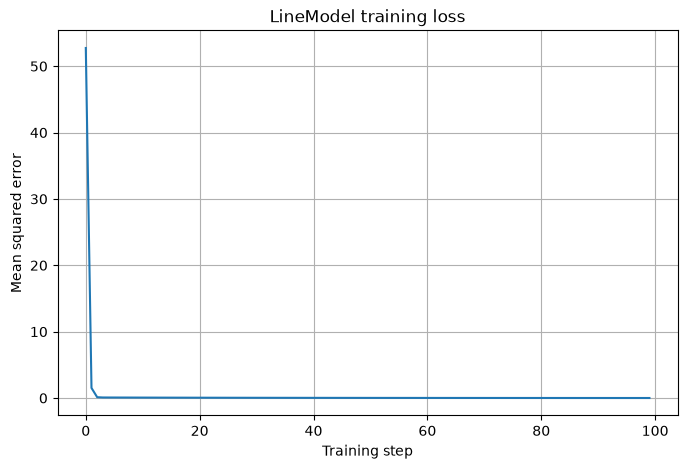

In [17]:
import matplotlib.pyplot as plt

training_steps = [int(row["step"]) for row in training_history]
training_losses = [row["loss"] for row in training_history]

plt.figure(figsize=(8, 5))
plt.plot(training_steps, training_losses)
plt.xlabel("Training step")
plt.ylabel("Mean squared error")
plt.title("LineModel training loss")
plt.grid(True)
plt.show()

The steep early decline shows that the model quickly approaches the line.

The smaller later changes refine the remaining weight and bias error.

## Plot the fitted line

Evaluate new drawing points under `torch.no_grad()` because visualization does not need a computation graph.

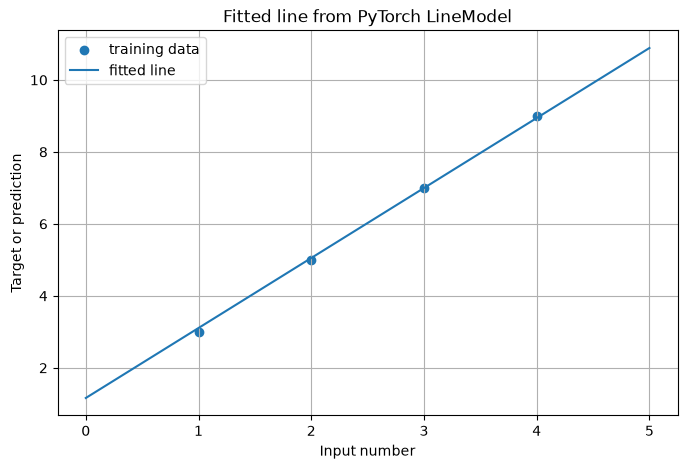

In [18]:
line_input_values = torch.linspace(
    0.0,
    5.0,
    steps=51,
    dtype=torch.float32,
    device=device,
).reshape(-1, 1)

with torch.no_grad():
    fitted_line_outputs = model(line_input_values)

plt.figure(figsize=(8, 5))
plt.scatter(
    input_numbers.squeeze(-1).cpu().numpy(),
    target_numbers.squeeze(-1).cpu().numpy(),
    label="training data",
)
plt.plot(
    line_input_values.squeeze(-1).cpu().numpy(),
    fitted_line_outputs.squeeze(-1).cpu().numpy(),
    label="fitted line",
)
plt.xlabel("Input number")
plt.ylabel("Target or prediction")
plt.title("Fitted line from PyTorch LineModel")
plt.legend()
plt.grid(True)
plt.show()

assert fitted_line_outputs.shape == line_input_values.shape

The fitted line passes close to every training point.

The small remaining discrepancy matches the nonzero final loss.

## Compare final predictions with targets

The table makes the remaining errors visible without relying only on the plot.

In [19]:
print("input | target | prediction | error")
print("-" * 45)

for input_value, target_value, prediction_value in zip(
    input_numbers.squeeze(-1),
    target_numbers.squeeze(-1),
    final_predictions.squeeze(-1),
    strict=True,
):
    prediction_error = prediction_value.item() - target_value.item()

    print(
        f"{input_value.item():>5.2f} | "
        f"{target_value.item():>6.2f} | "
        f"{prediction_value.item():>10.6f} | "
        f"{prediction_error:>8.6f}"
    )

input | target | prediction | error
---------------------------------------------
 1.00 |   3.00 |   3.106783 | 0.106783
 2.00 |   5.00 |   5.051744 | 0.051744
 3.00 |   7.00 |   6.996705 | -0.003295
 4.00 |   9.00 |   8.941665 | -0.058335


## Count parameters

A module's parameter count is the sum of `.numel()` over all registered parameter tensors.

For `Linear(in_features, out_features)` with a bias, the count is:

```text
out_features × in_features + out_features
```

In [20]:
def count_parameters(module: torch.nn.Module) -> int:
    return sum(parameter.numel() for parameter in module.parameters())


small_linear_layer = torch.nn.Linear(1, 1, device=device)
larger_linear_layer = torch.nn.Linear(3, 2, device=device)

print("Linear(1, 1) parameters:", count_parameters(small_linear_layer))
print("Linear(3, 2) parameters:", count_parameters(larger_linear_layer))
print("LineModel parameters:", count_parameters(model))

assert count_parameters(small_linear_layer) == 2
assert count_parameters(larger_linear_layer) == 8
assert count_parameters(model) == 2

Linear(1, 1) parameters: 2
Linear(3, 2) parameters: 8
LineModel parameters: 2


`Linear(3, 2)` has six weight values and two bias values.

Parameter objects are tensors, so one parameter object can contain many scalar trainable values.

## Modules can contain modules

A larger model can register several child layers.

This preview deliberately omits a nonlinearity, so the two affine layers still compose into one affine function.

In [21]:
class TwoLayerLinearModel(torch.nn.Module):
    first_linear_layer: torch.nn.Linear
    second_linear_layer: torch.nn.Linear

    def __init__(self) -> None:
        super().__init__()
        self.first_linear_layer = torch.nn.Linear(1, 4)
        self.second_linear_layer = torch.nn.Linear(4, 1)

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        hidden_values = self.first_linear_layer(input_values)
        assert isinstance(hidden_values, torch.Tensor)

        output_values = self.second_linear_layer(hidden_values)
        assert isinstance(output_values, torch.Tensor)
        return output_values


torch.manual_seed(RANDOM_SEED)
two_layer_model = TwoLayerLinearModel().to(device)
two_layer_outputs = two_layer_model(input_numbers)

print(two_layer_model)
print("Named parameters:")
for parameter_name, parameter in two_layer_model.named_parameters():
    print(parameter_name, parameter.shape)
print("Total scalar parameters:", count_parameters(two_layer_model))
print("Output shape:", two_layer_outputs.shape)

assert count_parameters(two_layer_model) == 13
assert two_layer_outputs.shape == torch.Size([4, 1])

TwoLayerLinearModel(
  (first_linear_layer): Linear(in_features=1, out_features=4, bias=True)
  (second_linear_layer): Linear(in_features=4, out_features=1, bias=True)
)
Named parameters:
first_linear_layer.weight torch.Size([4, 1])
first_linear_layer.bias torch.Size([4])
second_linear_layer.weight torch.Size([1, 4])
second_linear_layer.bias torch.Size([1])
Total scalar parameters: 13
Output shape: torch.Size([4, 1])


The first layer has eight parameters and the second has five, for a total of thirteen.

Recursive methods such as `parameters()`, `named_parameters()`, `state_dict()`, and `.to(device)` traverse this registered hierarchy.

## Registration requires PyTorch-aware storage

Assigning a `Parameter` or `Module` directly to a module attribute registers it.

Plain Python lists do not register items placed inside them.

Use containers such as `torch.nn.ParameterList`, `torch.nn.ParameterDict`, `torch.nn.ModuleList`, or `torch.nn.ModuleDict` when a model needs dynamic collections of registered objects.

## What not to do

- Do not omit `super().__init__()` from a module constructor.
- Do not hide parameters or child modules in ordinary Python containers.
- Do not call `forward` directly in normal model code.
- Do not describe a biased `nn.Linear` layer as a strictly linear mathematical map.
- Do not expect modules to clear accumulating gradients automatically.
- Do not update parameters through `.data`.
- Do not record manual parameter updates in the autograd graph.
- Do not add CUDA assumptions to this CPU-only course.

## Gotchas

- A `Parameter` requires gradients by default, but registration depends on where it is stored.
- A module can own parameters directly or inherit them recursively from child modules.
- `forward` describes computation, while `model(inputs)` uses the full module call path.
- `nn.Linear` stores weight with shape `[out_features, in_features]`.
- A state dictionary stores tensor state, not the model class.
- Parameter count means scalar values, not just the number of parameter tensors.

## Takeaways

`torch.nn.Module` organizes persistent model state and forward computation.

`torch.nn.Parameter` represents a trainable tensor that registers when assigned to a module.

`torch.nn.Linear` provides a standard affine layer with registered weight and bias parameters.

A model normally defines layers in `__init__`, defines data flow in `forward`, and is invoked with `model(inputs)`.

Recursive module methods make it possible to inspect, move, save, and train all parameters without listing each tensor manually.

The line model used the same autograd and update mathematics as Chapter 44, but its parameters now live in a reusable model structure.

## What comes next

The next chapter introduces PyTorch optimizers.

An optimizer receives `model.parameters()`, clears or updates their gradients, and replaces the manual `torch.no_grad()` update loop with the standard `zero_grad()` and `step()` interface.